In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from tqdm.notebook import trange
import cProfile, pstats, io
from pstats import SortKey
import warnings

In [2]:
def QFI(rho,G):
    # Input:
    #  - rho: the state
    #  - G: the generator of a Unitrary transform
    # Output: the QFI of the state with respect to that transform

    # Get the eigenstates, which gives us all the info we need to get the QFI
    (lambdas, Uw) = rho.eigenstates(output_type='oper')
    dims = G.dims
    U = qutip.dimensions.from_tensor_rep(np.reshape(qutip.dimensions.to_tensor_rep(Uw),np.array(dims).flatten()),dims)
    Gp = U.dag()*G*U
    [lambda1,lambda2] = np.meshgrid(lambdas,lambdas)

    # Vectorized logic to calculate the QFI
    # May be improved in the future, but works very well now
    matsize = [np.prod(dims[0]),np.prod(dims[1])]
    top = (lambda1-lambda2)**2
    prod = np.abs(np.reshape(qutip.dimensions.to_tensor_rep(Gp),matsize))**2
    bot = lambda1 + lambda2
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="invalid value encountered in divide")
        warnings.filterwarnings("ignore", message="divide by zero encountered in divide")
        FIs = np.where(bot>0,2*top*prod/bot,0)

    return np.sum(FIs)


In [3]:
def genChannel(dims=[5,5,5,6], params=[.1,.1]):
    eta = params[0]
    theta = np.arccos(np.sqrt(eta))
    nth = params[1]
    thdims = dims[0]
    sdims = dims[1]
    idims = dims[2]
    wdims = dims[3]
    # Create our transformation, and our state to compare with
    ath = tensor(destroy(thdims),identity(sdims))
    asi = tensor(identity(thdims),destroy(sdims)) # can't call this as, because it's a keyword
    G = theta *1j*(ath.dag()*asi +asi.dag()*ath)
    # Define the beamsplitter transform
    U = G.expm()
    pth = thermal_dm(thdims,nth)
    # Create a superoperator which performs the thermal mixing + tracing out
    S1=0
    for i in range(thdims):
        fockn = fock(thdims,i)
        pthket = pth*fockn
        ql = tensor(identity(sdims),pthket).drop_scalar_dims(inplace=True)
        qr = tensor(identity(sdims),fockn.dag()).drop_scalar_dims(inplace=True)
        S1 = S1+sprepost(ql,qr)
    S2 = sprepost(U,U.dag())*S1
    S3 = tensor_contract(S2,(1,3))
    # Defines a map that turns a 3 mode pure mode to a mixture of two
    # mode pure states with classical witnesses
    mixsup = sum([sprepost(fock_dm(wdims,i),fock_dm(wdims,i)) for i in range(wdims)])
    # Since each of these channels is a single field channel, we can
    # construct our whole channel via tensor product
    chan = super_tensor(S3,to_super(identity(idims)),mixsup)
    return chan

In [4]:
def searchForState(psi0=basis([5,5,6]), max_entropy=.01, epsilon=.1, iters=20000, dims=[5,5,5,6], params=[.1,.1]):
    # Set initial parameters
    eta = params[0]
    theta = np.arccos(np.sqrt(eta))
    nth = params[1]
    thdims = dims[0]
    sdims = dims[1]
    idims = dims[2]
    wdims = dims[3]
    overall_dims = dims[1:]

    # Create our transformation, and our state to compare with
    #ath = tensor(destroy(thdims),identity(sdims))
    #asi = tensor(identity(thdims),destroy(sdims)) # can't call this as, because it's a keyword
    #G = theta *1j*(ath.dag()*asi +asi.dag()*ath)
    # Define the beamsplitter transform
    #U = G.expm()
    #pth = thermal_dm(thdims,nth)
    # Create a superoperator which performs the thermal mixing + tracing out
    #S1=0
    #for i in range(thdims):
    #    fockn = fock(thdims,i)
    #    pthket = pth*fockn
    #    ql = tensor(identity(sdims),pthket).drop_scalar_dims(inplace=True)
    #    qr = tensor(identity(sdims),fockn.dag()).drop_scalar_dims(inplace=True)
    #    S1 = S1+sprepost(ql,qr)
    #S2 = sprepost(U,U.dag())*S1
    #S3 = tensor_contract(S2,(1,3))
    # Defines a map that turns a 3 mode pure mode to a mixture of two
    # mode pure states with classical witnesses
    #mixsup = sum([sprepost(fock_dm(wdims,i),fock_dm(wdims,i)) for i in range(wdims)])
    # Since each of these channels is a single field channel, we can
    # construct our whole channel via tensor product
    chan = genChannel(dims,params)#super_tensor(S3,to_super(identity(idims)),mixsup)
    # Define the thermal state when we mix in vacuum
    pth0 = thermal_dm(sdims,(1-eta)*nth)
    n = tensor(num(idims),identity(sdims),identity(wdims))
    rho0 = vector_to_operator(chan*operator_to_vector(psi0.proj()))

    state = psi0
    max_QFI = QFI(rho0,n)
    # Profiling code
    #pr = cProfile.Profile()
    #pr.enable()
    # rem = max_entropy
    for i in trange(iters):
        newstate = (state + epsilon*rand_ket(overall_dims)).unit()
        rho = vector_to_operator(chan*operator_to_vector(newstate.proj()))
        rel_ent = entropy_relative(pth0,rho.ptrace([0]),tol=1e-50)
        if(rel_ent <= max_entropy):
            FI = QFI(rho,n)
            if (FI >= max_QFI):
                max_QFI = FI
                # rem = max_entropy-rel_ent
                state = newstate
# Profiling code
#pr.disable()
#s2 = io.StringIO()
#sortby = SortKey.CUMULATIVE
#ps = pstats.Stats(pr, stream=s2).sort_stats(sortby)
#ps.print_stats()
#print(s2.getvalue())
    return state

In [5]:
state = searchForState()

  0%|          | 0/20000 [00:00<?, ?it/s]

In [6]:
n = tensor(num(5),identity(5),identity(6))
chan = genChannel()
pth0 = thermal_dm(5,(1-.1)*.1)
rho = vector_to_operator(chan*operator_to_vector(state.proj()))
rel_ent = entropy_relative(pth0,rho.ptrace([0]),tol=1e-50)
max_QFI = QFI(rho,n)
print(rel_ent)
print(max_QFI)

0.009987357397228058
0.17924264441921703


In [7]:
def calc_for_state(rho,n,As,args=[12,.1,.1]):
    # Input
    #  - rho: the initial state. The first field should be the signal field,
    #         all ancilla fields aren't impacted by our procedure
    #  - n: the number operator for the signal field
    #  - As: the annihilation operator for the signal field
    #  - args: an array of arguments that define our setup
    #    - 0: the number of dimensions to use for the thermal
    #         fields truncated Fock space
    #    - 1: the average photon number in the thermal field
    #    - 2: the transmisivity of our beamsplitter
    # Output
    #  - rel_ent: the quantum relative entropy between our state after mixing
    #             with thermal background, and the field without our input state
    #  - QFI: the quantum Fisher information of our state after mixing with
    #         thermal background
    # Description: Simulates a signal field mixed with a thermal background,
    #              and gives a measure of the effectiveness of a measurement
    #              and the detectability of our measurement to an adversary

    # Here we extract our parameters from our argument
    thdims = args[0]
    nth = args[1]
    eta = args[2]
    theta = np.arccos(np.sqrt(eta))
    
    # Since the thermal mixing is phase invariant, we don't need to worry about
    # when we pass through the sample. Putting the sample before or after the mixing
    # yields identical results. Additionally since phase transformations are unitary
    # we don't need to worry about applying it at all.
    pth = thermal_dm(thdims,nth)
    pth0 = thermal_dm(rho.dims[0][0],(1-eta)*nth)
    at = destroy(thdims)
    G = theta*(tensor(at.dag(),As)+tensor(at,As.dag()))*1j
    U = G.expm()
    st = tensor(pth, rho)
    stm = U*st*U.dag()

    # Tracing out the thermal mode should just involve doing a partial trace over
    # just the thermal mode. Unfortunately, QuTiP only exposes a function that
    # traces over all **but** the specified modes. Therefore, we just specify
    # all but the first mode
    tokeep = np.arange(1,len(stm.dims[0]))
    rhom = stm.ptrace(tokeep)

    # The adversary only has access to the signal mode when trying to determine
    # if we are making a measurement, so we trace over all other modes
    rel_ent = entropy_relative(pth0,rhom.ptrace([0]),tol=1e-50)
    
    FI = QFI(rhom,n)
    return [rel_ent,FI]

In [8]:
dim = 5
nth = .1
a = destroy(dim)
ad = a.dag()
iden = identity(dim)
pth = thermal_dm(dim,nth)
n = tensor(num(dim),iden)
a1 = tensor(a,iden)
theta = np.pi/2
zeroket = basis(dim,0)
oneket = basis(dim,1)
twoket = basis(dim,2)

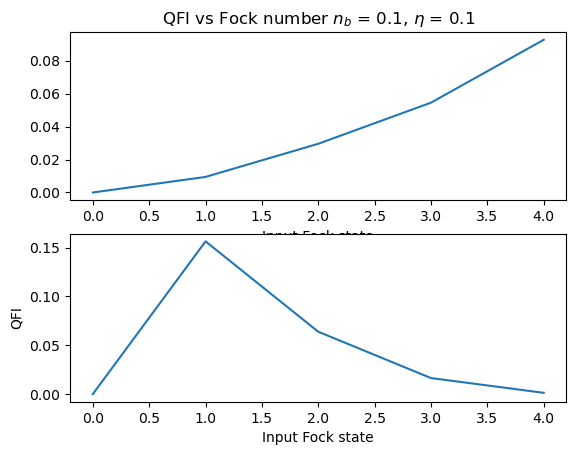

In [9]:
QFIs = np.zeros(dim)
REs = np.zeros(dim)
nth = .1
eta = .1
for i in range(dim):
    nket = basis(dim,i)
    unnorm = tensor(zeroket,nket) + tensor(nket,zeroket)
    statet = unnorm.proj().unit()
    [REs[i],QFIs[i]] = calc_for_state(statet,n,a1,[dim,nth,eta])
fig,ax = plt.subplots(2)
ax[0].set_xlabel('Input Fock state')
ax[1].set_xlabel('Input Fock state')
ax[1].set_ylabel('Relative Entropy')
ax[1].set_ylabel('QFI')
ax[0].set_title(r'Relative Entropy vs Fock number $n_b$ = {nb}, $\eta$ = {eta}'.format(nb=nth,eta=eta))
ax[0].set_title(r'QFI vs Fock number $n_b$ = {nb}, $\eta$ = {eta}'.format(nb=nth,eta=eta))
ax[0].plot(REs)
ax[1].plot(QFIs)

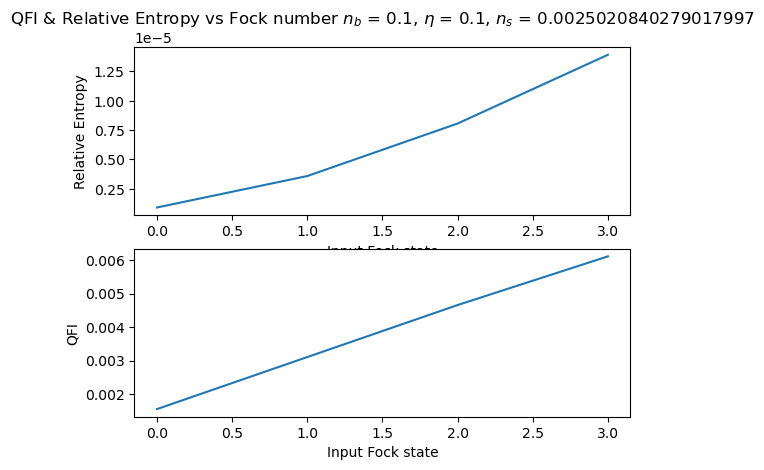

In [10]:
QFIs = np.zeros(4)
REs = np.zeros(4)
nth = .1
eta = .1
xsi = .13
S = squeezing(tensor(a,iden),tensor(iden,a),xsi)
sq = S*tensor(zeroket,zeroket)
for i in range(4):
    unnorm = a1**i * sq
    statet = unnorm.unit().proj()
    [REs[i],QFIs[i]] = calc_for_state(statet,n,a1,[dim,nth,eta])
fig,ax = plt.subplots(2)
ax[0].set_xlabel('Input Fock state')
ax[1].set_xlabel('Input Fock state')
ax[0].set_ylabel('Relative Entropy')
ax[1].set_ylabel('QFI')
ax[0].set_title(r'QFI & Relative Entropy vs Fock number $n_b$ = {nb}, $\eta$ = {eta}, $n_s$ = {nsq}'.format(nb=nth,eta=eta,nsq = np.sinh(eta/2)**2))
ax[0].plot(REs)
ax[1].plot(QFIs)

[0.63203797 0.08128455 0.11405376 0.06543904 0.05948253 0.04770215]


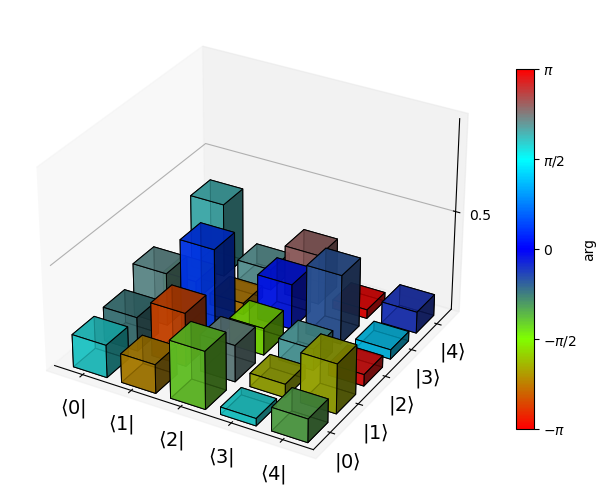

In [11]:
states = []
wdims = 6
sdims = 5
idims = 5
probabilities = np.zeros(wdims)
for i in range(wdims):
    staten = tensor(identity(sdims),identity(idims),basis(wdims,i).dag())*state
    probabilities[i] = staten.norm()**2
    toadd = qutip.dimensions.from_tensor_rep(np.reshape(qutip.dimensions.to_tensor_rep(staten.unit()),[sdims,idims]),[[sdims],[idims]])
    states.append(toadd)
print(probabilities)
[fig,ani] = anim_matrix_histogram(states,bar_style='abs',color_style='phase',options={'bars_alpha':.8})
HTML(ani.to_jshtml())

In [12]:
states = []
wdims = 6
sdims = 5
idims = 5
probabilities = np.zeros(wdims)
n = tensor(num(sdims),identity(idims))
chan = genChannel()
rho = vector_to_operator(chan*operator_to_vector(state.proj()))
QFIs = np.zeros(wdims)
for i in range(wdims):
    staten = (tensor(identity(sdims),identity(idims),basis(wdims,i).dag())*rho*tensor(identity(sdims),identity(idims),basis(wdims,i))).drop_scalar_dims(inplace=True)
    probabilities[i] = staten.norm()
    QFIs[i] = QFI(staten.unit(),n)
print(probabilities)
print(QFIs)
print(np.sum(probabilities*QFIs))

[0.63203797 0.08128455 0.11405376 0.06543904 0.05948253 0.04770215]
[0.03936921 0.53030312 0.28908052 0.45181898 0.40842743 0.51198405]
0.1792426444192168


In [13]:
adverstate = state.ptrace([0])
nbar = expect(num(sdims),adverstate)
print(nbar)
thermeq = thermal_dm(sdims,nbar)
entropy_relative(thermeq,adverstate)

0.518244592379975


np.float64(0.0797548614587974)

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

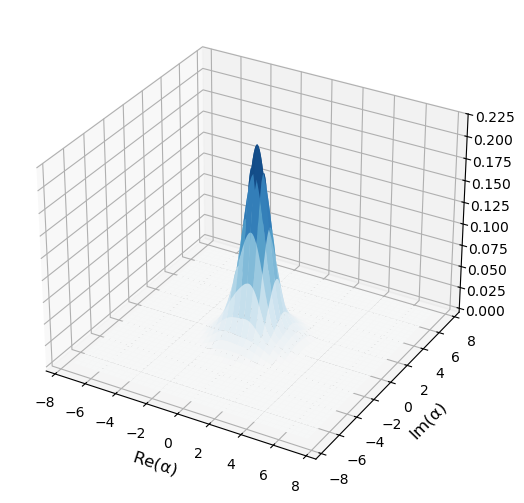

In [14]:
plot_wigner(adverstate,projection='3d')

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

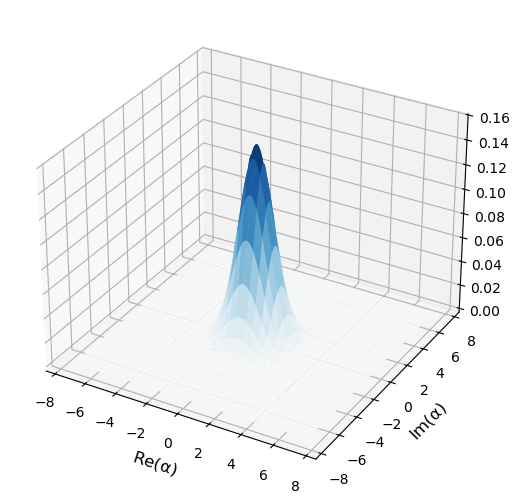

In [15]:
plot_wigner(thermeq,projection='3d')

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

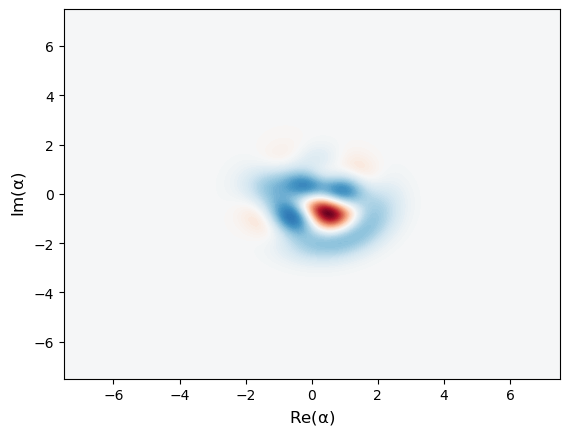

In [16]:
plot_wigner(rand_ket(5))